# Dataset Statistics
Please find the original generated event logs for the purpose of SHAining into Process Discovery as a [Zenodo Artifact](https://zenodo.org/records/15047390). This notebook presents event log statistics and characteristics. 

In [1]:
import pandas as pd
DATA_PATH = "../data/icpm_25/8_aq1_ekbr3_nusa_rt5v_svo_saq1_tlkh_tlv_allfeatures_stats.csv"
REAL_PATH = "../data/icpm_25/bpic_features_p.csv"

In [2]:
df = pd.read_csv(REAL_PATH)
gen =pd.read_csv(DATA_PATH)

#paper_cols = ["log","ratio_variants_per_number_of_traces", "ratio_most_common_variant", 'ratio_top_10_variants', 'epa_normalized_variant_entropy', 'epa_normalized_sequence_entropy', 'epa_normalized_sequence_entropy_linear_forgetting', 'epa_normalized_sequence_entropy_exponential_forgetting'] 
#df= df[paper_cols]

print(gen.shape, df.shape)
df['source']='Real'
gen['source']='Generated'
both_df = pd.concat([df, gen])
print(both_df.shape)
both_df.head()
#print(gen.columns == df.columns)

(62027, 80) (34, 101)
(62061, 104)


,log,n_traces,n_unique_traces,ratio_unique_traces_per_trace,trace_len_min,trace_len_max,trace_len_mean,trace_len_median,trace_len_mode,trace_len_std,...,normalized_variant_entropy,sequence_entropy,normalized_sequence_entropy,sequence_entropy_linear_forgetting,normalized_sequence_entropy_linear_forgetting,sequence_entropy_exponential_forgetting,normalized_sequence_entropy_exponential_forgetting,source,n_variants,ratio_variants_per_number_of_traces
0,BPIC16c_p,226,99.0,0.438053,1,5,1.278761,1.0,1,0.642995,...,0.899497,1.119782e+03,0.683796,662.711695,0.404685,769.861437,0.470116,Real,NaN,NaN
1,BPIC16q_p,21533,17171.0,0.797427,1,102,5.730878,4.0,1,5.485213,...,0.813468,1.093881e+06,0.756132,614708.751793,0.424910,732191.123578,0.506118,Real,NaN,NaN
2,BPIC16wm_p,16653,48.0,0.002882,1,61,3.966733,3.0,1,4.203692,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,Real,NaN,NaN
3,BPIC15f1,1199,1170.0,0.975813,2,101,43.550459,44.0,44,16.981536,...,0.652855,3.461843e+05,0.610294,153292.220991,0.270241,206434.994626,0.363928,Real,NaN,NaN
4,BPIC15f2,832,828.0,0.995192,1,132,53.310096,54.0,61,19.894977,...,0.627973,2.858769e+05,0.602371,150546.571682,0.317217,185312.937423,0.390473,Real,NaN,NaN


In [3]:
import numpy as np
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit(both_df.drop(['log','source'], axis=1))
imp_df = imp_mean.transform(both_df.drop(['log','source'], axis=1))
imp_df = pd.DataFrame(imp_df, columns = both_df.columns[2:])
print("Before:", len(both_df.loc[:, both_df.isna().any()].columns), "columns in", len(both_df.loc[:, both_df.isna().any()]), 'rows')
print("After:", len(imp_df.loc[:, imp_df.isna().any()].columns))

Before: 37 columns in 62061 rows
After: 0


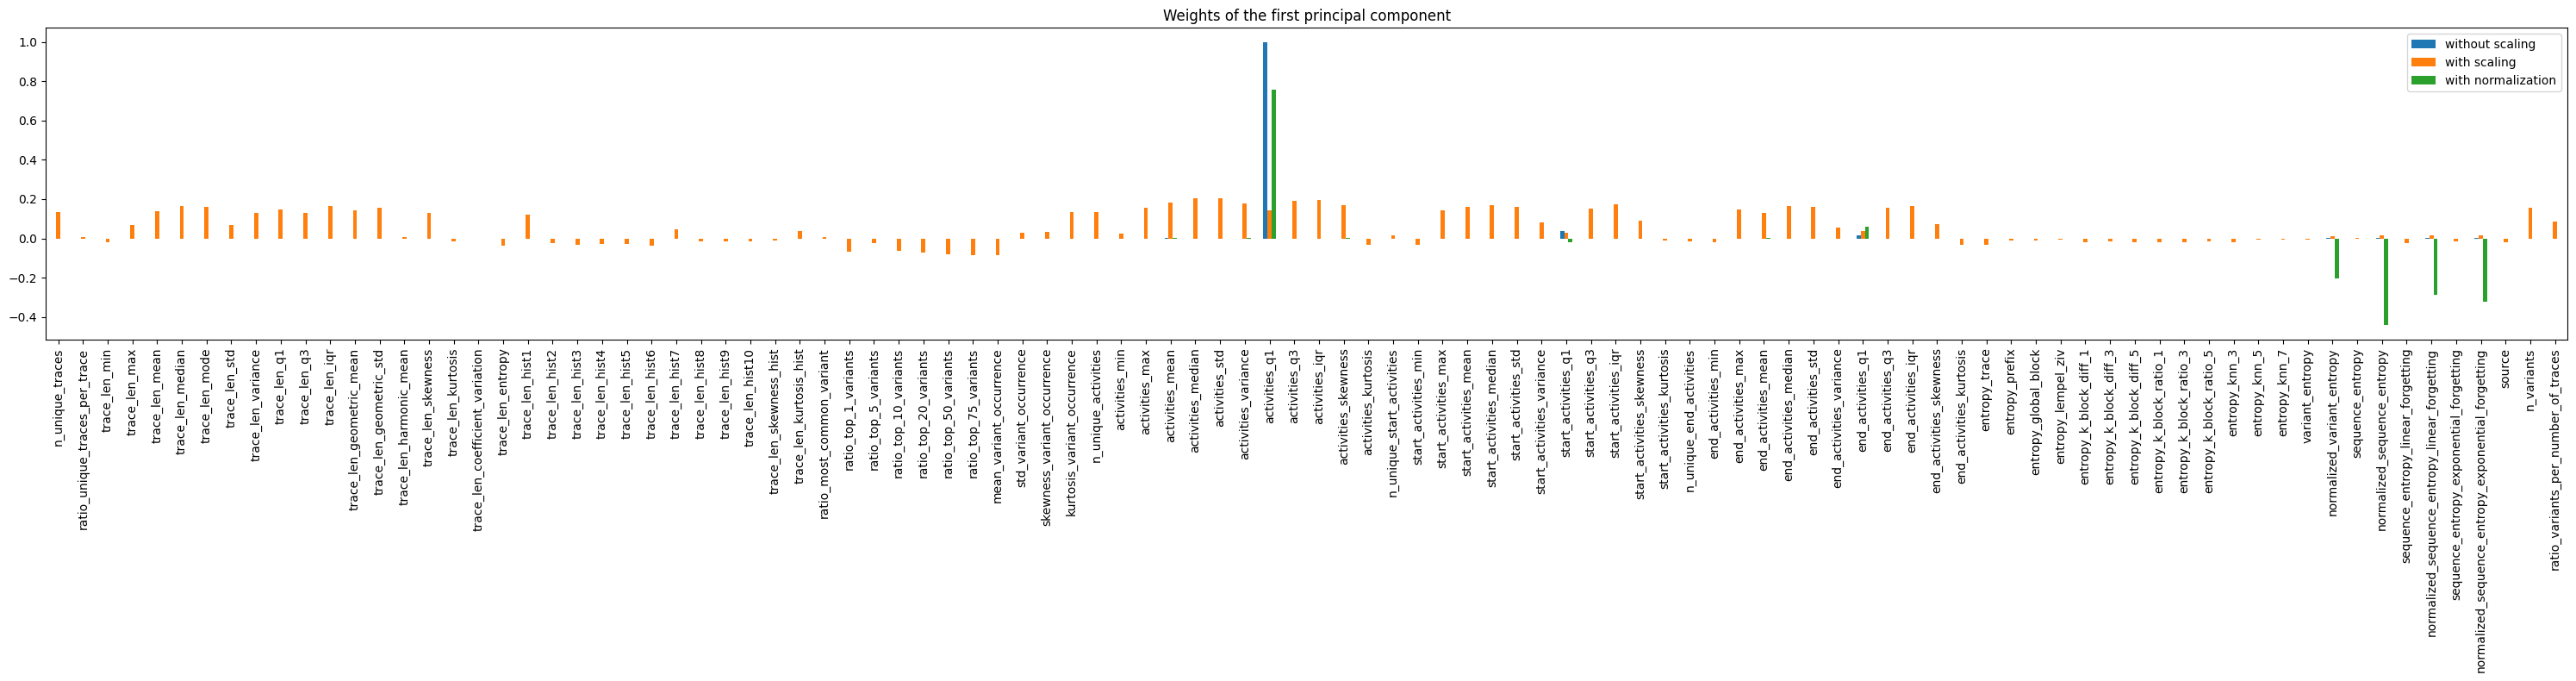

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

X = imp_df
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X)
normed_X = Normalizer(norm="l2").fit_transform(X)


import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2).fit(X)
scaled_pca = PCA(n_components=2).fit(scaled_X_train)
norm_pca = PCA(n_components=2).fit(normed_X)


X_train_transformed = pca.transform(X)
X_train_std_transformed = scaled_pca.transform(scaled_X_train)
X_train_norm_transformed = norm_pca.transform(normed_X)


first_pca_component = pd.DataFrame(
    pca.components_[0], index=X.columns, columns=["without scaling"]
)
first_pca_component["with scaling"] = scaled_pca.components_[0]
first_pca_component["with normalization"] = norm_pca.components_[0]
first_pca_component.plot.bar(
    title="Weights of the first principal component", figsize=(30, 8)
)

_ = plt.tight_layout()

../output/plots/pca_BpicsVsGen.png


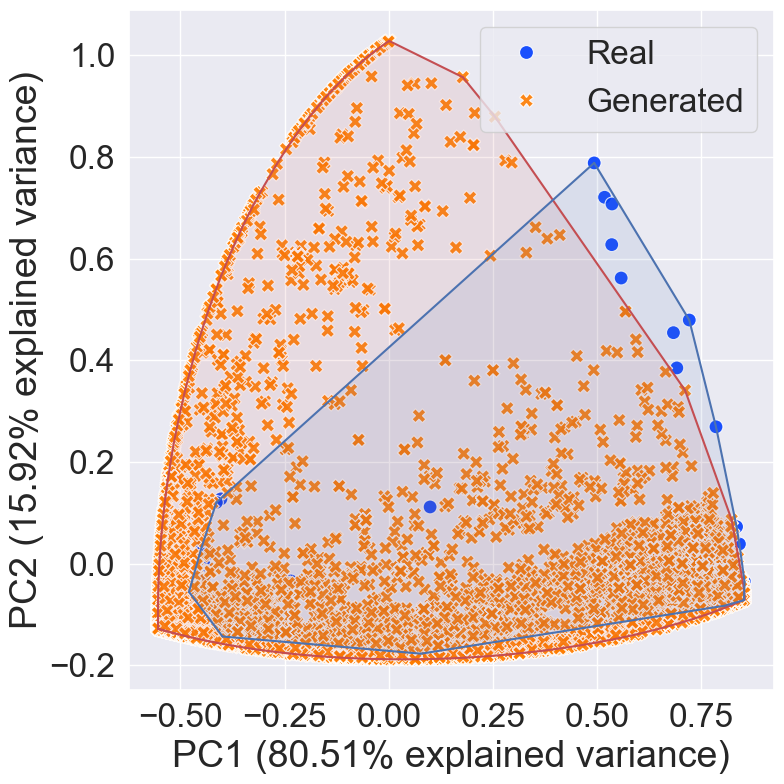

In [6]:
FONTSIZE=24
sns.set_theme()
fig, ax1 = plt.subplots(1,1,figsize=(8, 8))

X_new = pca.fit_transform(norm_data)
df_pca = pd.DataFrame(X_new, columns=["PC1", "PC2"])
df_pca['source']=both_df['source'].to_numpy()
numbers_gen = df_pca[df_pca['source'] == 'Generated'][['PC1', 'PC2']].to_numpy()
numbers_real = df_pca[df_pca['source'] == 'Real'][['PC1', 'PC2']].to_numpy()

sns.scatterplot(ax=ax1, data=df_pca, x="PC1", y="PC2", palette="bright", hue='source',
                alpha=0.9, s=100, style="source")
plot_convex_hull(numbers_gen, ax1, 'r-', 'r')
plot_convex_hull(numbers_real, ax1, 'b-', 'b')

ax1.set_xlabel(f"PC1 ({np.round(pca.explained_variance_ratio_[0]*100, 2)}% explained variance)", fontsize=FONT_SIZE+7)
ax1.set_ylabel(f"PC2 ({np.round(pca.explained_variance_ratio_[1]*100, 2)}% explained variance)", fontsize=FONT_SIZE+7)
ax1.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
ax1.tick_params(axis='both', which='minor', labelsize=FONT_SIZE)
ax1.legend(prop={'size': FONT_SIZE})

plt.yticks(fontsize=FONTSIZE)
plt.xticks(fontsize=FONTSIZE)
plt.legend(fontsize=FONTSIZE)
#plt.xticks(rotation=-30)

plt.tight_layout()
output_path = f"../output/plots/pca_BpicsVsGen.png"
print(output_path)
plt.savefig(output_path, dpi=300, transparent=True)